# 03 — Liquidation capacity

Provenance first: the cell below reads this loop's `manifest.json` and prints it.
If it raises, record provenance before computing anything.

The capacity model itself runs in `mrsearch.liq_capacity` (the risk-engine
writer); this notebook reads the written `outputs/liq_capacity` rows plus the
raw inputs they came from, and produces the cross-section charts and tables
the README reports.

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from mrsearch import SnapshotReader, read_manifest
from mrsearch.outputs import LIQ_CAPACITY, OutputStore

manifest = read_manifest(Path.cwd())
print(manifest)

DATA = Path.cwd().parents[1] / "data"
r = SnapshotReader(DATA)
pd.set_option("display.width", 220)

MODEL_VERSION = "metron-v1.3.0+390430e"  # pinned: model 1.1
V1_VERSION = "metron-v1.3.0+15811c5"  # the pre-correction series, for the comparison cell
cap_all = OutputStore(DATA).read(LIQ_CAPACITY)
cap = cap_all[cap_all.model_version == MODEL_VERSION].copy()
AS_OF = pd.Timestamp(cap.as_of.max()).tz_convert("UTC")
cap = cap[cap.as_of == cap.as_of.max()]
print(f"{len(cap_all)} rows total, {len(cap)} in this cross-section")
print("model_version:", MODEL_VERSION, "| cycle:", AS_OF)

Manifest(snapshot_date='2026-08-17', mnemon_commit='f2b6b8d57371a61972fb95855c46740b205c9040', metron_version='v1.3.0', tables=('dex_quotes', 'core_book_levels', 'core_assets', 'markets', 'market_state', 'prices', 'outputs/liq_capacity'))


11180 rows total, 65 in this cross-section
model_version: metron-v1.3.0+390430e | cycle: 2026-08-17 08:00:00+00:00


## Cross-section summary

One row per market at the cycle. `capacity_total_usd = capacity_evm_usd +
capacity_core_usd`; `capacity_ratio` divides by outstanding borrow (ASOF-priced
at the cycle). Statuses: `ok`, `no_route` (the aggregator cannot route the
pair at any size), `no_price` (the pair was never quoted this cycle).

In [2]:
sym = r.sql(
    "SELECT market_id, collateral_symbol || '/' || loan_symbol AS pair, "
    "collateral_symbol, collateral_token, loan_token, lltv::DOUBLE/1e18 AS lltv FROM markets"
)
m = cap.merge(sym, on="market_id", how="left")
b = m[m.outstanding_borrow_usd > 0].copy()

print("status:", m.status.value_counts().to_dict(), "| censored:", int(m.capacity_censored.sum()))
print(f"markets with borrow: {len(b)}")
print(f"total borrow ${b.outstanding_borrow_usd.sum()/1e6:.1f}M, "
      f"total modeled capacity ${b.capacity_total_usd.sum()/1e6:.1f}M")
print("capacity_ratio quantiles:",
      b.capacity_ratio.quantile([0.1, 0.25, 0.5, 0.75, 0.9]).round(3).to_dict())
print(f"markets with ratio >= 1: {int((b.capacity_ratio >= 1).sum())} of {len(b)}")

core = m[m.capacity_core_usd > 0]
print(f"core-mapped rows: {len(core)}; core share of their capacity: "
      f"{core.capacity_core_usd.sum()/core.capacity_total_usd.sum():.3f}")

ok = m[m.status == "ok"]
print("capacity_evm_usd quantiles (ok rows):",
      ok.capacity_evm_usd.quantile([0.25, 0.5, 0.75, 0.95]).round(0).to_dict())

top = b.sort_values("outstanding_borrow_usd", ascending=False).head(15)
cols = ["pair", "lltv", "max_slippage_used", "fee_ref", "capacity_evm_usd",
        "capacity_core_usd", "capacity_ratio", "capacity_ratio_grouped",
        "outstanding_borrow_usd", "status"]
print(top[cols].round(3).to_string(index=False))

top5 = b.nlargest(5, "outstanding_borrow_usd")
top5_share = top5.outstanding_borrow_usd.sum() / b.outstanding_borrow_usd.sum()
print(f"\ntop-5 borrow share: {top5_share:.1%}; "
      f"their pooled ratio: {top5.capacity_total_usd.sum()/top5.outstanding_borrow_usd.sum():.3f}")
print("no_route pairs:", sorted(m[m.status == "no_route"].pair.dropna().unique()))
print("no_route borrow $:", round(m[m.status == "no_route"].outstanding_borrow_usd.sum()))

grp = (b.groupby("collateral_symbol")
       .agg(group_borrow=("outstanding_borrow_usd", "sum"),
            grouped_ratio=("capacity_ratio_grouped", "max"))
       .sort_values("group_borrow", ascending=False))
print("\ncollateral groups (grouped ratio shown for the group's best market):")
print(grp.head(8).round(4).to_string())

status: {'ok': 55, 'no_route': 7, 'no_price': 2, 'fee_exceeds_margin': 1} | censored: 0
markets with borrow: 64
total borrow $99.7M, total modeled capacity $83.1M
capacity_ratio quantiles: {0.1: 0.0, 0.25: 0.036, 0.5: 1.228, 0.75: 20.236, 0.9: 554.185}
markets with ratio >= 1: 34 of 64
core-mapped rows: 29; core share of their capacity: 0.977
capacity_evm_usd quantiles (ok rows): {0.25: 1623.0, 0.5: 11543.0, 0.75: 55540.0, 0.95: 144683.0}
         pair  lltv  max_slippage_used  fee_ref  capacity_evm_usd  capacity_core_usd  capacity_ratio  capacity_ratio_grouped  outstanding_borrow_usd             status
   WHYPE/USDC 0.770              0.061    0.003        127143.292        2961957.590           0.075                   0.064            38596197.600                 ok
  kHYPE/WHYPE 0.860              0.036    0.001        517201.657           3256.986           0.032                   0.011            15707507.237                 ok
   kHYPE/USDC 0.625              0.107    0.000      

## Chart 1 — slippage ladders and where the threshold cuts them

Four of the largest-borrow markets with distinct pairs. Each panel: the
cycle's quoted slippage curve (log size), the market's max tolerable
liquidation slippage `x` (dashed), and the modeled DEX capacity where the
interpolated curve first crosses it (dot). The $1k reference rung (slippage 0 by
construction) and negative-slippage quotes fall off the log axis and are
not drawn; the capacity computation uses them. The curves collapse in the
50k–500k region regardless of pair — the venue's depth wall.

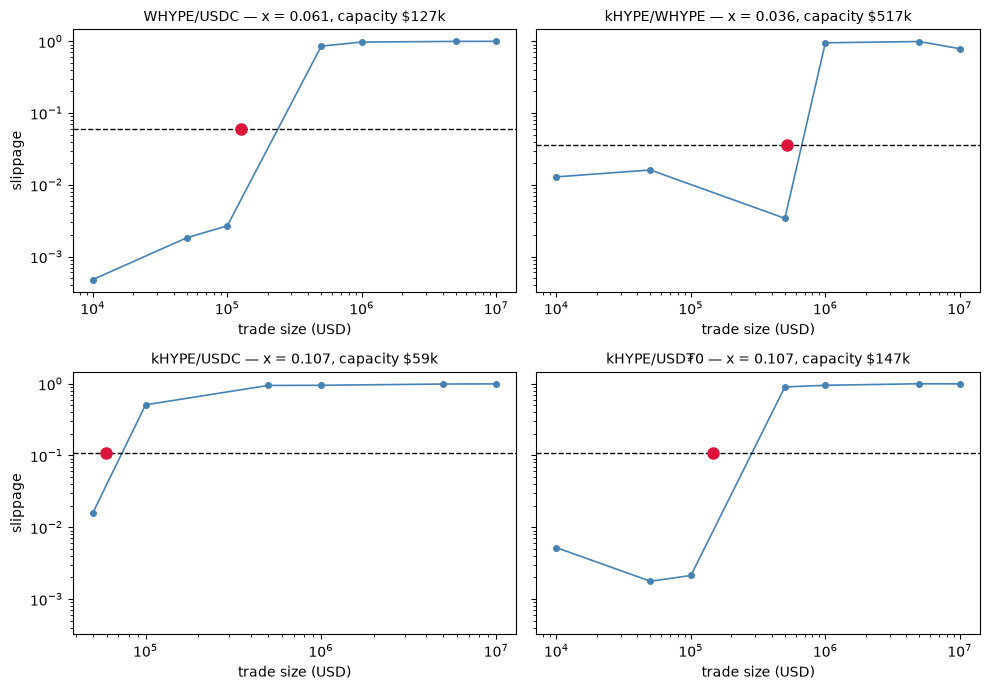

In [3]:
picks = (b[b.status == "ok"].sort_values("outstanding_borrow_usd", ascending=False)
         .drop_duplicates("pair").head(4))

fig, axes = plt.subplots(2, 2, figsize=(10, 7), sharey=True)
for ax, row in zip(axes.flat, picks.itertuples(), strict=False):
    lad = r.sql(
        "SELECT size_usd, slippage FROM v_dex_slippage "
        "WHERE ts = ?::TIMESTAMPTZ AND token_in = ? AND token_out = ? AND slippage > 0 "
        "ORDER BY size_usd",
        [AS_OF.isoformat(), row.collateral_token, row.loan_token],
    )
    ax.plot(lad.size_usd, lad.slippage, "o-", color="steelblue", ms=4, lw=1.2)
    ax.axhline(row.max_slippage_used, color="black", lw=1, ls="--")
    ax.plot([row.capacity_evm_usd], [row.max_slippage_used], "o", color="crimson", ms=8, zorder=5)
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_title(f"{row.pair} — x = {row.max_slippage_used:.3f}, "
                 f"capacity ${row.capacity_evm_usd/1e3:.0f}k", fontsize=10)
    ax.set_xlabel("trade size (USD)")
axes[0, 0].set_ylabel("slippage")
axes[1, 0].set_ylabel("slippage")
fig.tight_layout()
fig.savefig("assets/slippage_ladders.png", dpi=150, bbox_inches="tight")

## Chart 2 — capacity against outstanding borrow

Every market with borrow, log-log. The diagonals are ratio guides: a market
below the ratio = 1 line owes more than the model says liquidators can clear
within the incentive. Orange markets carry a HyperCore book add-on.

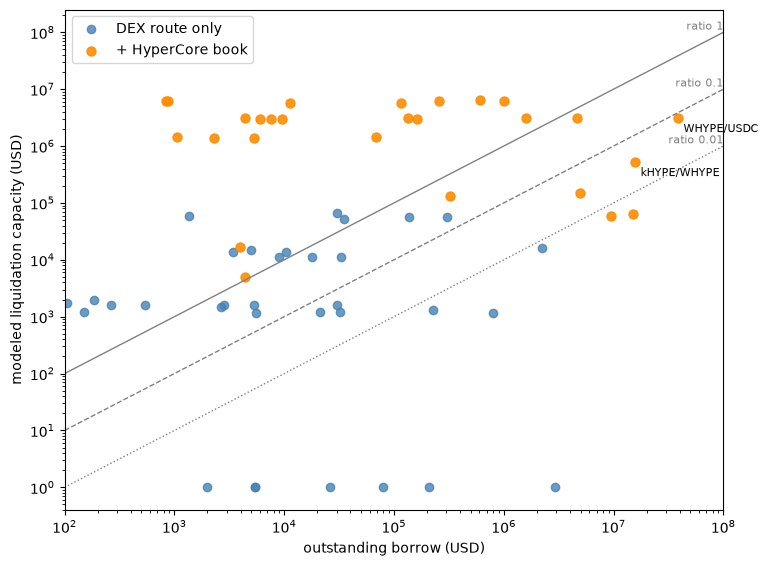

In [4]:
fig, ax = plt.subplots(figsize=(8.5, 6.5))
has_core = b.capacity_core_usd > 0
floor = 1.0  # log axis cannot show 0; zero-capacity rows are drawn at the floor
tot = b.capacity_total_usd.clip(lower=floor)
ax.scatter(b.outstanding_borrow_usd[~has_core], tot[~has_core],
           s=36, alpha=0.8, color="steelblue", label="DEX route only")
ax.scatter(b.outstanding_borrow_usd[has_core], tot[has_core],
           s=42, alpha=0.9, color="darkorange", label="+ HyperCore book")
lims = np.array([1e2, 1e8])
for k, style in [(1.0, "-"), (0.1, "--"), (0.01, ":")]:
    ax.plot(lims, lims * k, style, color="gray", lw=1)
    ax.annotate(f"ratio {k:g}", (lims[1], lims[1] * k), fontsize=8,
                color="gray", ha="right", va="bottom")
for row in b.nlargest(2, "outstanding_borrow_usd").itertuples():
    ax.annotate(row.pair, (row.outstanding_borrow_usd, max(row.capacity_total_usd, floor)),
                fontsize=8, xytext=(4, -10), textcoords="offset points")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlim(1e2, 1e8)
ax.set_xlabel("outstanding borrow (USD)")
ax.set_ylabel("modeled liquidation capacity (USD)")
ax.legend(loc="upper left")
fig.savefig("assets/capacity_vs_borrow.png", dpi=150, bbox_inches="tight")

## Chart 3 — coverage of the twelve largest debt stacks

Capacity ratio (log scale) for the twelve markets that owe the most, sorted
by borrow. The vertical line is ratio = 1: full coverage within the
incentive-tolerable slippage.

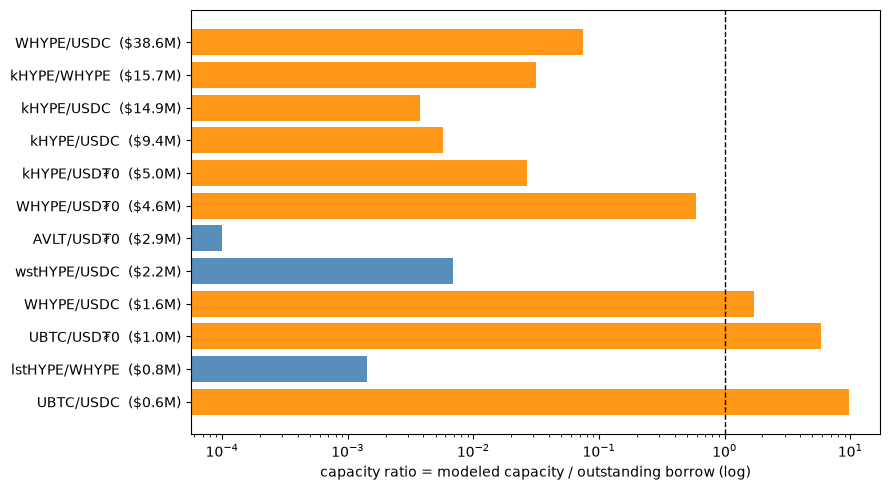

In [5]:
t12 = b.nlargest(12, "outstanding_borrow_usd").iloc[::-1]
labels = [f"{row.pair}  (${row.outstanding_borrow_usd/1e6:.1f}M)" for row in t12.itertuples()]
colors = ["darkorange" if c > 0 else "steelblue" for c in t12.capacity_core_usd]
ratios = t12.capacity_ratio.clip(lower=1e-4)

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(labels, ratios, color=colors, alpha=0.9)
ax.axvline(1.0, color="black", lw=1, ls="--")
ax.set_xscale("log")
ax.set_xlabel("capacity ratio = modeled capacity / outstanding borrow (log)")
fig.tight_layout()
fig.savefig("assets/capacity_ratio_top.png", dpi=150, bbox_inches="tight")

## v1 vs v1.1 comparison

Same cycle, both model versions. v1.1 changes two things: the threshold
subtracts the $1k reference route's blended fee (capacity can only fall),
and the grouped ratio divides by the collateral group's summed borrow
(a second, stricter reading — the isolated ratio is unchanged in meaning).

In [6]:
shared = sorted(set(cap_all[cap_all.model_version == V1_VERSION].as_of)
                & set(cap_all[cap_all.model_version == MODEL_VERSION].as_of))
CMP_TS = shared[-1]
old = cap_all[(cap_all.model_version == V1_VERSION) & (cap_all.as_of == CMP_TS)]
new = cap_all[(cap_all.model_version == MODEL_VERSION) & (cap_all.as_of == CMP_TS)]
j = old.merge(new, on="market_id", suffixes=("_v1", "_v11"))
print(f"comparison cycle: {pd.Timestamp(CMP_TS).tz_convert('UTC')} ({len(j)} markets)")

moved = j[j.status_v1 != j.status_v11]
print(f"status changes: {len(moved)}")
if len(moved):
    print(moved.groupby(["status_v1", "status_v11"]).size().to_string())

j["fee_effect"] = j.capacity_total_usd_v1 - j.capacity_total_usd_v11
print(f"\nfee_ref quantiles: {new.fee_ref.quantile([0.25, 0.5, 0.75, 1.0]).round(4).to_dict()}")
print(f"markets with capacity reduced by the fee correction: "
      f"{(j.fee_effect > 0).sum()} of {len(j)}")
big = j.nlargest(5, "fee_effect")[["market_id", "fee_effect",
                                   "capacity_total_usd_v1", "capacity_total_usd_v11"]]
big["market_id"] = big["market_id"].str[:10]
print("largest capacity reductions (USD):")
print(big.round(0).to_string(index=False))

iso = new[new.capacity_ratio.notna()]
print(f"\nisolated vs grouped ratio at the comparison cycle "
      f"(medians): {iso.capacity_ratio.median():.3f} vs "
      f"{iso.capacity_ratio_grouped.median():.3f}; markets where grouped < isolated: "
      f"{(iso.capacity_ratio_grouped < iso.capacity_ratio).sum()} of {len(iso)}")

comparison cycle: 2026-08-16 23:00:00+00:00 (65 markets)
status changes: 1
status_v1  status_v11        
ok         fee_exceeds_margin    1

fee_ref quantiles: {0.25: 0.0006, 0.5: 0.0015, 0.75: 0.0036, 1.0: 0.021}
markets with capacity reduced by the fee correction: 56 of 65
largest capacity reductions (USD):
 market_id  fee_effect  capacity_total_usd_v1  capacity_total_usd_v11
0x964e7d1d    151128.0              1650018.0               1498890.0
0x6eb4ce92     35964.0              6927419.0               6891455.0
0xa24d04c3     35964.0              6927419.0               6891455.0
0x5ef35fe4     35914.0              6875541.0               6839627.0
0xa6232764     31866.0              1688539.0               1656673.0

isolated vs grouped ratio at the comparison cycle (medians): 1.207 vs 0.040; markets where grouped < isolated: 51 of 64


## Recomputability

Any written row rebuilds from its own `params` + `input_window` plus the raw
MNEMON inputs. The cell below re-derives the largest market's row end to end
and asserts equality — the check that makes the table auditable months later.

In [7]:
from metron import liquidation_capacity

from mrsearch.liq_capacity import (
    CORE_COIN_BY_SYMBOL,
    blended_route_fee,
    capacity_ratios,
    core_depth_within,
)
from mrsearch.protocol import lif_from_lltv, max_slippage_threshold

row = b.nlargest(1, "outstanding_borrow_usd").iloc[0]
params, window = json.loads(row.params), json.loads(row.input_window)

x_pre = max_slippage_threshold(row.lltv, params["haircut"])
assert abs(x_pre - row.x_pre_fee) < 1e-15
lad_q = r.sql(
    "SELECT size_usd, slippage, route_json FROM v_dex_slippage d "
    "LEFT JOIN dex_quotes q USING (ts, chain_id, token_in, token_out, size_usd) "
    "WHERE d.ts = ?::TIMESTAMPTZ AND d.token_in = ? AND d.token_out = ? AND d.status = 'ok'",
    [window["dex_as_of"], row.collateral_token, row.loan_token],
).sort_values("size_usd")
fee = blended_route_fee(json.loads(lad_q.route_json.iloc[0]))
assert abs(fee - row.fee_ref) < 1e-15
x_used = max(0.0, x_pre - fee)
assert abs(x_used - row.max_slippage_used) < 1e-15

lad = lad_q.dropna(subset=["slippage"]).set_index("size_usd")["slippage"]
evm, censored = liquidation_capacity(lad, x_used)
assert abs(evm - row.capacity_evm_usd) < 1e-6 and censored == row.capacity_censored

core_usd = 0.0
if window["core_book_as_of"] is not None:
    book = r.sql(
        "SELECT depth_bps, bid_depth_usd FROM v_core_depth WHERE ts = ?::TIMESTAMPTZ AND coin = ?",
        [window["core_book_as_of"], CORE_COIN_BY_SYMBOL[row.collateral_symbol]],
    ).set_index("depth_bps")["bid_depth_usd"]
    core_usd = core_depth_within(book, x_used)
assert abs(core_usd - row.capacity_core_usd) < 1e-6

lif = lif_from_lltv(row.lltv)
ratio, grouped = capacity_ratios(
    evm + core_usd, lif, row.outstanding_borrow_usd, row.collateral_group_borrow_usd
)
assert abs(ratio - row.capacity_ratio) < 1e-12
assert abs(grouped - row.capacity_ratio_grouped) < 1e-12
print(f"{row.pair}: x {x_pre:.4f} - fee {fee:.4f} -> {x_used:.4f}; "
      f"evm {evm:,.2f} + core {core_usd:,.2f} = {evm + core_usd:,.2f}; "
      f"ratios {ratio:.4f} / {grouped:.4f} (grouped) — "
      "recomputed exactly from row metadata + raw inputs")

WHYPE/USDC: x 0.0640 - fee 0.0035 -> 0.0605; evm 127,143.29 + core 2,961,957.59 = 3,089,100.88; ratios 0.0745 / 0.0637 (grouped) — recomputed exactly from row metadata + raw inputs
